## Nichtlineare Randwertprobleme in einer Dimension
Das nichtlineare Randwertproblem
$$
    y'' = g(x, y), \quad y(a) = y_0, \quad y(b) = y_n
$$

wird mit äquidistanten Stützpunkten 

$$
    x_i = a + i \cdot \frac{b-a}{n} \quad (0 \leq i \leq n)
$$

diskretisiert. Für die Stützwerte 

$$
    y_i \approx y(x_i)
$$

ergibt sich mit zentralen Differenzenquotienten
$$
    y_i'' \approx \frac{y_{i+1} - 2 y_i + y_{i-1}}{h^2}
$$

das nichtlineare Gleichungssystem

$$
    y_{i+1} - 2 y_i + y_{i-1} - h^2 g(x_i, y_i) = 0, \qquad ( 0 < i < n)
$$

für die inneren Punkte. Dies kann mit dem Newtonverfahren gelöst werden. Gesucht ist eine Nullstelle von 

$$
    f(\vec{y}) = \begin{pmatrix} 
        y_{0} - 2 y_1 + y_{2} - h^2 g(x_1, y_1) \\
        y_{1} - 2 y_2 + y_{3} - h^2 g(x_2, y_2) \\
        \vdots \\
        y_{n-2} - 2 y_{n-1} + y_{n} - h^2 g(x_{n-1}, y_{n-1}) \\
    \end{pmatrix} \stackrel!= \vec{0} \in \mathbb{R}^{n-1}
$$

Die Jacobimatrix 

$$
    J \in \mathbb{R}^{(n-1) \times (n-1)}
$$
von $\vec{f}$ ist tridiagonal mit den Diagonalen

$$
    \vec{d}_{-1} = \vec{d}_{+1} = 1, \qquad \vec{d}_{0} = - 2 - h^2 \cdot g_{.y} (\vec{x}, \vec{y})
$$

Es lohnt sich hier durchaus, den Thomas-Algorithmus für die Lösung des LGS zu verwenden.

### Thomas Algorithmus
Aus P3a übernommen

In [1]:
import numpy as np
"""
LU decomposition for tridiagonal matrix
in: a  =  [[0,      a_{10}, ..., a_{n-2,n-3}, a_{n-1,n-2}],
           [a_{00}, a_{11}, ..., a_{n-2,n-2}, a_{n-1,n-1}],
           [a_{01}, a_{12}, ..., a_{n-2,n-1},   0]]

out: LU = [[0,      l_{10}, ..., l_{n-2,n-3}, l_{n-1,n-2}],
           [r_{00}, r_{11}, ..., r_{n-2,n-2}, r_{n-1,n-1}],
           [r_{01}, r_{12}, ..., r_{n-2,n-1},   0]]
"""

def ind(i, j):
    if (i == j+1):   return 0, i
    if (i == j):     return 1, i
    if (i == j - 1): return 2, i
    assert(False)

def LR_tri(m):
    n = m.shape[1]
    LR = np.zeros_like(m)
    LR[ind(0,0)] = m[ind(0,0)]
    for j in range(1, n):
        LR[ind(j, j-1)] = m[ind(j,j-1)] / LR[ind(j-1, j-1)]
        LR[ind(j-1, j)] = m[ind(j-1, j)]
        LR[ind(j,j)]    = m[ind(j,j)] - LR[ind(j, j-1)] * LR[ind(j-1, j)]
    return LR

# Vorwärts-Rückwärtseinsetzen
"""
in: LU (output von LR_tri), Vektor b
out: Vektor x s.t. L@U@x == b
"""  
def fbSub_tri(LR, b):
    n = b.shape[0]
    
    y = np.zeros_like(b)
    y[0] = b[0] 
    for i in range(1, n):
        y[i] = (b[i] - LR[ind(i, i-1)] * y[i-1])     
        
    x = np.zeros_like(y)
    x[-1] = y[-1] / LR[ind(n-1, n-1)]
    for i in range(n-2, -1, -1):
        x[i] = (y[i] - LR[ind(i, i+1)] * x[i+1]) / LR[ind(i, i)]  

    return x

# Lineares Gleichungssystem mit tridiagonaler Koeffizentenmatrix lösen
def linsolve_tri(m, b):
    LR = LR_tri(m)
    return fbSub_tri(LR, b)

### Randwertproblem
Wir lösen das Randwertproblem 

$$
    y'' = 50 \, x \, \sin(3 \, x + y^2), \quad y(-3) = 1, \,\, y(5) = 1
$$

Für die Newtoniteration benötigen wir gemäss dem obigen die Ableitung der Funktion $g(x, y)$ nach $y$:

$$
    g_{.y} = 100 \, x \, y \cos(3 \, x + y^2)
$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt

n = 500         # n+1 Punkte x0 ... xn für die Unterteilung
h = 1/n
a, b = -3, 5   # Intervall x \in [a, b]
y0, yn = 1, 1 # Randwerte

# %% ode ist y'' = g(x, y) und dg ist die partielle Ableitung von g nach y
g  = lambda x, y:   50 * x * np.sin(3*x+y**2)
dg = lambda x, y:   100 * x * y * np.cos(3*x+y**2) # partielle Ableitung von g nach y (xi sind fest!)

x = np.linspace(a, b, n+1) # diskretisiertes x-Intervall

# Funktion für Newton (gsucht ist y mit f(y) = 0)
f = lambda y: y[2:] - 2 * y[1:-1] + y[:-2] - h**2 * g(x[1:-1], y[1:-1])

# Jacobimatrix dazu, zuerst als "volle" (n-1) x (n-1) Matrix
J = lambda y: np.diag(np.ones(n-2), -1) + np.diag(- 2 - h**2 * dg(x[1:-1], y[1:-1])) + np.diag (np.ones(n-2),1)

# Die Jacobimatrix in "kompakter Form", gemäss P3a
Jm = lambda y: np.array([np.ones(n-1), - 2 - h**2 * dg(x[1:-1], y[1:-1]), np.ones(n-1)])

Im folgenden plot werden  

* linkes die Startwerte (einfach ein linspace zwischen $y_0$ und $y_n$) zusammen mit den Zwischenpunkten der Iteration
* rechts die Differenz zwischen der numerische Ableitung $y''$ (Differenzenquotienten) und der Funktion $g$

dargestellt.


0.003053318041496865
0.003487875976463695
0.0003584261166614755
0.0022862597757341225
0.00012099717511121048
0.0006031511650281726
1.1005157584326554e-05
6.698799509997337e-06
2.4201122100047604e-09
4.4616119882216986e-13
3.716998580591863e-15
3.80011885902703e-15


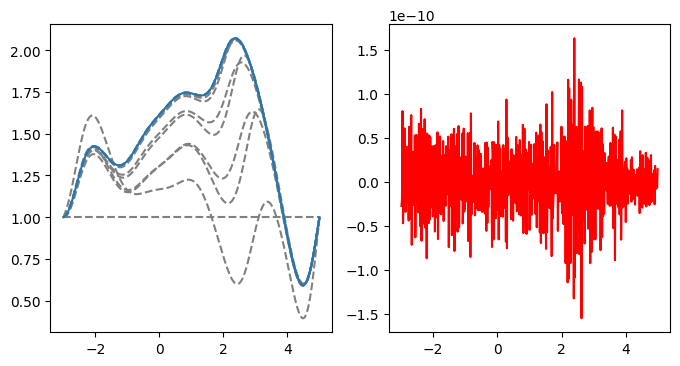

In [7]:
# Startwert für y, mit Randwerten
y = np.linspace(y0, yn, n+1)  
y[0], y[-1] = y0, yn            # Randwerte

# Newtonverfahren mit plots
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
delta = 1 # dummy, wg. Abbruchbedingung. delta ist in Wirklichkeit ein Vektor in R^{n-1}!
while (np.linalg.norm(delta) > 1e-12):
    ax[0].plot(x, y, color = "gray", linestyle = "--", )
    # delta = np.linalg.solve(J(y), f(y))
    delta = linsolve_tri(Jm(y), f(y)) # effizientere Variante
    y[1:-1] -= delta # Randwerte in y bleiben bestehen
    print(np.linalg.norm(f(y)))
    
# %%
ax[0].plot(x, y)
ax[1].plot(x[1:-1], np.diff(np.diff(y)) / h**2 - g(x[1:-1], y[1:-1]), color = "r")
